In [1]:
import pandas as pd

In [2]:
dfq=pd.read_csv('BASE_B2B_CLV_32.csv')
print(dfq.columns)

C:\Users\ltequia\AppData\Local\Temp\ipykernel_19460\1931805049.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  dfq=pd.read_csv('BASE_B2B_CLV_32.csv')


Index(['PERIODO', 'CLIENTE_ID', 'CLIENTE', 'VALOR_FACTURACION',
       'VALOR_FACTURADO_3M', 'RGU_TOTAL', 'NUM_LINEAS', 'NUM_PRODUCTOS',
       'MESES_ANTIGUEDAD', 'EJECUTIVO', 'SEGMENTO_2026', 'REGIONAL',
       'DEPARTAMENTO', 'MUNICIPIO', 'LINEA', 'PRODUCTO_H', 'CONVERGENCIA',
       'CONVERGENCIA_2', 'FIRST_LEVEL', 'CLV', 'CLV_GRUPO', 'GESTOR'],
      dtype='object')


In [3]:
print(dfq["CLV"].value_counts())

CLV
1.00    958657
2.00    133639
2.50    109812
1.50    104760
3.00     97560
         ...  
3.40         3
2.55         3
8.05         2
7.80         2
2.90         2
Name: count, Length: 321, dtype: int64


In [4]:
print(dfq['PERIODO'].unique())
## dejar solo el periodo 2025-09-01

['2025-01-01' '2025-02-01' '2025-03-01' '2025-04-01' '2025-05-01'
 '2025-06-01' '2025-07-01' '2025-08-01' '2025-09-01' '2025-10-01'
 '2025-11-01' '2025-12-01' '2026-01-01' '2026-02-01' '2026-03-01'
 '2026-04-01' '2026-05-01']


In [5]:
print(dfq['FIRST_LEVEL'].value_counts())

FIRST_LEVEL
FIJO       952106
MOVIL      806876
DIGITAL     18916
Name: count, dtype: int64


In [6]:
# === 3. Agrupar por PERIODO, sumar y contar clientes únicos ===
resumen = (
    dfq.groupby("PERIODO", as_index=False)
       .agg({
           "VALOR_FACTURADO_3M": "sum",
           "RGU_TOTAL": "sum",
           "CLIENTE_ID": "nunique"  # clientes únicos
       })
       .rename(columns={"CLIENTE_ID": "CLIENTES_UNICOS"})
       .sort_values("PERIODO")
)

# === 4. Formatear con separador de miles ===
resumen["VALOR_FACTURADO_3M"] = resumen["VALOR_FACTURADO_3M"].apply(lambda x: f"{x:,.0f}".replace(",", "."))
resumen["RGU_TOTAL"] = resumen["RGU_TOTAL"].apply(lambda x: f"{x:,.0f}".replace(",", "."))
resumen["CLIENTES_UNICOS"] = resumen["CLIENTES_UNICOS"].apply(lambda x: f"{x:,.0f}".replace(",", "."))

# === 5. Mostrar resultado ===
print("📊 Suma de VALOR_FACTURACION, RGU_TOTAL y CLIENTES ÚNICOS por PERIODO:\n")
print(resumen.to_string(index=False))

📊 Suma de VALOR_FACTURACION, RGU_TOTAL y CLIENTES ÚNICOS por PERIODO:

   PERIODO VALOR_FACTURADO_3M RGU_TOTAL CLIENTES_UNICOS
2025-01-01     73.045.137.382   399.885         121.584
2025-02-01     79.325.595.718   391.532         123.923
2025-03-01     84.664.804.987   405.514         129.016
2025-04-01     85.923.401.173   399.685         134.469
2025-05-01     87.866.713.766   396.942         141.507
2025-06-01     89.477.415.110   393.285         147.504
2025-07-01     89.603.042.030   382.532         155.564
2025-08-01     93.232.022.297   381.781         163.357
2025-09-01     94.641.955.656   394.698         172.329
2025-10-01     95.600.602.802   391.684         181.164
2025-11-01     97.282.076.781   390.348         190.483
2025-12-01    102.499.838.195   383.689         201.286
2026-01-01     98.899.403.693   372.114         193.599
2026-02-01     98.869.124.383   202.857         187.353
2026-03-01     98.905.115.989   368.425         181.262
2026-04-01     98.372.589.939   3

In [7]:
df2= pd.read_excel('Clientes con sectores.xlsx')
print(df2.columns)

Index(['CLIENTE_ID', 'NIT_9', 'NIT', 'NIT_CRUCE_MDO', 'CLIENTE', 'CIIU',
       'SECTOR', 'TIPO_SERVICIO', 'PORTAFOLIO', 'SEGMENTO_2025',
       'SEGMENTO_2026', 'FACURACION_PROM_2025 (JUL-SEP)', 'BASE'],
      dtype='object')


In [8]:
print(dfq['CLV_GRUPO'].unique())

['Blindaje' 'Rentabilización' 'Penetración']


In [9]:
import pandas as pd
import numpy as np

# =====================================
# 1️⃣ NORMALIZAR CLIENTE_ID
# =====================================
dfq['CLIENTE_ID'] = dfq['CLIENTE_ID'].astype(str).str.strip()
df2['CLIENTE_ID'] = df2['CLIENTE_ID'].astype(str).str.strip()

# =====================================
# 2️⃣ CREAR BASE DE CLIENTES (DESDE dfq)
# =====================================
clientes_base = (
    dfq[['CLIENTE_ID']]
    .dropna()
    .drop_duplicates()
)

print("Clientes únicos base:", clientes_base['CLIENTE_ID'].nunique())

# =====================================
# 3️⃣ TOMAR ÚLTIMO REGISTRO HISTÓRICO POR CLIENTE
# (LA LÓGICA CLAVE DE TU SCRIPT ORIGINAL)
# =====================================
dfq_ultimos = (
    dfq.sort_values(['CLIENTE_ID', 'PERIODO'])
       .groupby('CLIENTE_ID', as_index=False)
       .last()
)

print("Clientes con último histórico:", dfq_ultimos['CLIENTE_ID'].nunique())

# =====================================
# 4️⃣ CREAR CONSOLIDADO BASE
# =====================================
df_consolidado = clientes_base.merge(
    dfq_ultimos,
    on='CLIENTE_ID',
    how='left'
)

# =====================================
# 5️⃣ RELLENAR VALORES FALTANTES (INTELIGENTE)
# =====================================
columnas_valores = [c for c in dfq.columns if c not in ['CLIENTE_ID', 'PERIODO']]

for col in columnas_valores:
    if col in df_consolidado.columns:
        if col == 'CLV_GRUPO':
            df_consolidado[col] = df_consolidado[col].fillna('Penetración')
        elif pd.api.types.is_numeric_dtype(dfq[col]):
            df_consolidado[col] = df_consolidado[col].fillna(0)
        else:
            df_consolidado[col] = df_consolidado[col].fillna("")

# =====================================
# 6️⃣ TRAER SOLO SECTOR DESDE df2 (SIN DUPLICADOS)
# =====================================
df2_sector = (
    df2[['CLIENTE_ID', 'SECTOR']]
    .drop_duplicates(subset='CLIENTE_ID')
)

df_consolidado = df_consolidado.merge(
    df2_sector,
    on='CLIENTE_ID',
    how='left'
)

# =====================================
# 7️⃣ ASIGNAR PERIODO CONSOLIDADO
# =====================================
df_consolidado['PERIODO'] = 'Consolidado'

# =====================================
# 8️⃣ VALIDACIÓN CLAVE
# =====================================
print("\n📊 VALIDACIÓN CONSOLIDADO")
print("Clientes únicos consolidado:",
      df_consolidado['CLIENTE_ID'].nunique())

print("Filas consolidado:", len(df_consolidado))

# =====================================
# 9️⃣ UNIR CON HISTÓRICO ORIGINAL (SIN ALTERAR HISTORIA)
# =====================================
dfq_actualizado = pd.concat(
    [dfq, df_consolidado],
    ignore_index=True
)

# =====================================
# 🔟 VALIDACIÓN FINAL DE INTEGRIDAD
# =====================================
print("\n📊 VALIDACIÓN FINAL DATASET")
print("Filas dfq original      :", len(dfq))
print("Filas consolidadas añad :", len(df_consolidado))
print("Filas totales finales   :", len(dfq_actualizado))

print("\nClientes únicos finales:",
      dfq_actualizado['CLIENTE_ID'].nunique())

# =====================================
# 1️⃣1️⃣ PRINT COLUMNAS FINALES
# =====================================
print("\n====== COLUMNAS FINALES dfq_actualizado ======")
print(dfq_actualizado.columns.tolist())

# Preview
print("\n🔎 Preview consolidado:")
print(df_consolidado.head())

Clientes únicos base: 201286
Clientes con último histórico: 201286

📊 VALIDACIÓN CONSOLIDADO
Clientes únicos consolidado: 201286
Filas consolidado: 201286

📊 VALIDACIÓN FINAL DATASET
Filas dfq original      : 2772274
Filas consolidadas añad : 201286
Filas totales finales   : 2973560

Clientes únicos finales: 201286

====== COLUMNAS FINALES dfq_actualizado ======
['PERIODO', 'CLIENTE_ID', 'CLIENTE', 'VALOR_FACTURACION', 'VALOR_FACTURADO_3M', 'RGU_TOTAL', 'NUM_LINEAS', 'NUM_PRODUCTOS', 'MESES_ANTIGUEDAD', 'EJECUTIVO', 'SEGMENTO_2026', 'REGIONAL', 'DEPARTAMENTO', 'MUNICIPIO', 'LINEA', 'PRODUCTO_H', 'CONVERGENCIA', 'CONVERGENCIA_2', 'FIRST_LEVEL', 'CLV', 'CLV_GRUPO', 'GESTOR', 'SECTOR']

🔎 Preview consolidado:
   CLIENTE_ID      PERIODO                          CLIENTE  \
0           0  Consolidado                     LUZ GONZALEZ   
1  1000001645  Consolidado  SINDI PAOLA RODRIGUEZ RODRIGUEZ   
2  1000002446  Consolidado        JUAN FELIPE GARZON DUARTE   
3  1000002516  Consolidado      

In [10]:
df= dfq_actualizado

In [11]:
# === 3. Agrupar por PERIODO y sumar ===
resumen = (
    df.groupby("PERIODO", as_index=False)[["VALOR_FACTURADO_3M", "RGU_TOTAL"]]
      .sum()
      .sort_values("PERIODO")
)

# === 4. Formatear con separador de miles ===
resumen["VALOR_FACTURADO_3M"] = resumen["VALOR_FACTURADO_3M"].apply(lambda x: f"{x:,.0f}".replace(",", "."))
resumen["RGU_TOTAL"] = resumen["RGU_TOTAL"].apply(lambda x: f"{x:,.0f}".replace(",", "."))

# === 5. Mostrar resultado ===
print("📊 Suma de VALOR_FACTURACION y RGU_TOTAL por PERIODO MES_LIMPIO:\n")
print(resumen.to_string(index=False))

📊 Suma de VALOR_FACTURACION y RGU_TOTAL por PERIODO MES_LIMPIO:

    PERIODO VALOR_FACTURADO_3M RGU_TOTAL
 2025-01-01     73.045.137.382   399.885
 2025-02-01     79.325.595.718   391.532
 2025-03-01     84.664.804.987   405.514
 2025-04-01     85.923.401.173   399.685
 2025-05-01     87.866.713.766   396.942
 2025-06-01     89.477.415.110   393.285
 2025-07-01     89.603.042.030   382.532
 2025-08-01     93.232.022.297   381.781
 2025-09-01     94.641.955.656   394.698
 2025-10-01     95.600.602.802   391.684
 2025-11-01     97.282.076.781   390.348
 2025-12-01    102.499.838.195   383.689
 2026-01-01     98.899.403.693   372.114
 2026-02-01     98.869.124.383   202.857
 2026-03-01     98.905.115.989   368.425
 2026-04-01     98.372.589.939   367.405
 2026-05-01     97.460.243.496   360.697
Consolidado     99.369.047.008   365.598


In [12]:
print(df['PERIODO'].unique())

['2025-01-01' '2025-02-01' '2025-03-01' '2025-04-01' '2025-05-01'
 '2025-06-01' '2025-07-01' '2025-08-01' '2025-09-01' '2025-10-01'
 '2025-11-01' '2025-12-01' '2026-01-01' '2026-02-01' '2026-03-01'
 '2026-04-01' '2026-05-01' 'Consolidado']


In [13]:
print(df.columns)

Index(['PERIODO', 'CLIENTE_ID', 'CLIENTE', 'VALOR_FACTURACION',
       'VALOR_FACTURADO_3M', 'RGU_TOTAL', 'NUM_LINEAS', 'NUM_PRODUCTOS',
       'MESES_ANTIGUEDAD', 'EJECUTIVO', 'SEGMENTO_2026', 'REGIONAL',
       'DEPARTAMENTO', 'MUNICIPIO', 'LINEA', 'PRODUCTO_H', 'CONVERGENCIA',
       'CONVERGENCIA_2', 'FIRST_LEVEL', 'CLV', 'CLV_GRUPO', 'GESTOR',
       'SECTOR'],
      dtype='object')


In [14]:
## cantiidad de CLIENTE_ID unicos por SEGMENTO_2026
print(df.groupby('SEGMENTO_2026')['CLIENTE_ID'].nunique())
## de esos CLIENTE_ID unicos, en que PERIODO estan
print(df.groupby(['SEGMENTO_2026','PERIODO'])['CLIENTE_ID'].nunique())


SEGMENTO_2026
Empresas                     5666
Gobierno                      509
Large                        1570
Multinacionales               450
SOHO                       150809
Small                       41908
Wholesale International        58
Wholesale Others              316
Name: CLIENTE_ID, dtype: int64
SEGMENTO_2026     PERIODO    
Empresas          2025-01-01     5332
                  2025-02-01     5357
                  2025-03-01     5384
                  2025-04-01     5400
                  2025-05-01     5433
                                 ... 
Wholesale Others  2026-02-01      303
                  2026-03-01      300
                  2026-04-01      297
                  2026-05-01      293
                  Consolidado     316
Name: CLIENTE_ID, Length: 144, dtype: int64


In [15]:
## Validar cantidad de clientes que no se unieron
missing_segmento = df['SEGMENTO_2026'].isnull().sum()
missing_sector = df['SECTOR'].isnull().sum()
print(f'Clientes sin SEGMENTO_2026: {missing_segmento}')
print(f'Clientes sin SECTOR: {missing_sector}')


Clientes sin SEGMENTO_2026: 0
Clientes sin SECTOR: 2835104


In [16]:
df3 = pd.read_csv('Sector.csv', sep=';')

# Normalizar clave
df['CLIENTE_ID'] = df['CLIENTE_ID'].astype(str).str.strip()
df3['CLIENTE_ID'] = df3['CLIENTE_ID'].astype(str).str.strip()

# Quitar duplicados en df3 (MUY IMPORTANTE)
df3_sector = df3[['CLIENTE_ID', 'SECTOR']].drop_duplicates(subset='CLIENTE_ID')

# Merge seguro
df_final = df.merge(
    df3_sector,
    on='CLIENTE_ID',
    how='left',
    suffixes=('', '_from_df3')
)

# Rellenar solo nulos
df_final['SECTOR'] = df_final['SECTOR'].combine_first(df_final['SECTOR_from_df3'])

# Validación de impacto
asignados = (
    df_final['SECTOR_from_df3'].notna() &
    df['SECTOR'].isna()
).sum()

print(f"Clientes que recibieron SECTOR desde df3: {asignados}")

# Limpiar columna auxiliar
df_final.drop(columns=['SECTOR_from_df3'], inplace=True)

# Corrección real de SEGMENTO
df_final['SEGMENTO_2026'] = df_final['SEGMENTO_2026'].fillna(df_final['SEGMENTO_2026'])
df_final['SEGMENTO_2026'] = df_final['SEGMENTO_2026'].replace('Micro/Small', 'Small')

# Validaciones finales
print("Nulos finales en SECTOR:", df_final['SECTOR'].isna().sum())
print("Nulos finales en SEGMENTO_2026:", df_final['SEGMENTO_2026'].isna().sum())

C:\Users\ltequia\AppData\Local\Temp\ipykernel_19460\1221111095.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('Sector.csv', sep=';')


Clientes que recibieron SECTOR desde df3: 497206
Nulos finales en SECTOR: 2337898
Nulos finales en SEGMENTO_2026: 0


In [17]:
## dame los valores de la columna SEGMENTO_2026 y SECTOR y la cantidad de clientes en cada uno de ellos
segmento_counts = df_final['SEGMENTO_2026'].value_counts()
sector_counts = df_final['SECTOR'].value_counts()
print("Cantidad de Clientes por SEGMENTO_2026:")
print(segmento_counts)
print("\nCantidad de Clientes por SECTOR:")
print(sector_counts)


Cantidad de Clientes por SEGMENTO_2026:
SEGMENTO_2026
SOHO                       2105835
Small                       717202
Empresas                     99448
Large                        27696
Gobierno                      8981
Multinacionales               7919
Wholesale Others              5459
Wholesale International       1020
Name: count, dtype: int64

Cantidad de Clientes por SECTOR:
SECTOR
Promedio                                          199157
Mayoristas y detal                                 75980
OTRAS INDUSTRIAS                                   72375
Servicios profesionales                            59171
Transporte                                         28549
Productos de consumo                               28310
Construcción, materiales y recursos naturales      24141
Manufactura                                        16496
COMERCIO AL DETALLE                                15103
Proveedores de servicios de salud                  14904
Servicios Financieros y de Ba

✅ Cantidad de Clientes por SEGMENTO_2026 y SECTOR (17 categorías):
        SEGMENTO_2026            SECTOR_17  CANT_CLIENTES
11           Empresas     OTRAS INDUSTRIAS           1730
3            Empresas   COMERCIO MAYORISTA           1038
2            Empresas  COMERCIO AL DETALLE            672
9            Empresas          MANUFACTURA            625
12           Empresas                SALUD            466
..                ...                  ...            ...
106  Wholesale Others         CONSTRUCCIÓN             12
104  Wholesale Others  COMERCIO AL DETALLE              8
108  Wholesale Others          MANUFACTURA              2
107  Wholesale Others           FINANCIERO              1
109  Wholesale Others     OIL & GAS/MINING              1

[113 rows x 3 columns]

✅ Cantidad total de Clientes por SECTOR_17:
SECTOR_17
OTRAS INDUSTRIAS       77376
COMERCIO AL DETALLE    19934
COMERCIO MAYORISTA     13373
MANUFACTURA             8496
ALIMENTOS Y BEBIDAS     6508
CONSTRUCCIÓN 

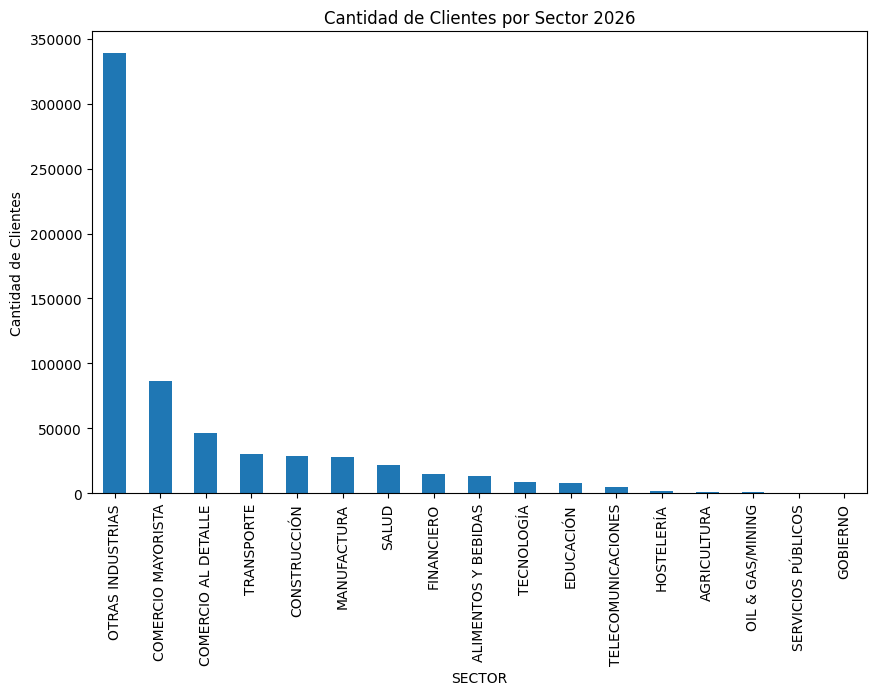

In [18]:
import pandas as pd

# 1️⃣ Normalizar nombres de SECTOR (mayúsculas y quitar espacios)
df_final['SECTOR'] = df_final['SECTOR'].str.upper().str.strip()

# 2️⃣ Mapeo de sectores a 17 grandes grupos
map_sector = {
    'COMERCIO AL DETALLE': 'COMERCIO AL DETALLE',
    'COMERCIO MAYORISTA': 'COMERCIO MAYORISTA',
    'MAYORISTAS Y DETAL': 'COMERCIO MAYORISTA',
    'PRODUCTOS DE CONSUMO': 'COMERCIO AL DETALLE',
    'ALIMENTOS Y BEBIDAS': 'ALIMENTOS Y BEBIDAS',
    'PROCESAMIENTO DE ALIMENTOS Y BEBIDAS': 'ALIMENTOS Y BEBIDAS',
    'MANUFACTURA': 'MANUFACTURA',
    'PRODUCTOS FARMACEUTICOS Y MÉDICOS': 'SALUD',
    'PROVEEDORES DE SERVICIOS DE SALUD': 'SALUD',
    'SERVICIOS SALUD': 'SALUD',
    'SERVICIOS PROFESIONALES': 'OTRAS INDUSTRIAS',
    'SERVICIOS EDUCATIVOS': 'EDUCACIÓN',
    'EDUCACIÓN': 'EDUCACIÓN',
    'CONSTRUCCIÓN': 'CONSTRUCCIÓN',
    'CONSTRUCCIÓN, MATERIALES Y RECURSOS NATURALES': 'CONSTRUCCIÓN',
    'TRANSPORTE': 'TRANSPORTE',
    'TECNOLOGÍA': 'TECNOLOGÍA',
    'DESARROLLO DE SOFTWARE Y SERVICIOS DE INTERNET': 'TECNOLOGÍA',
    'TELECOMUNICACIONES': 'TELECOMUNICACIONES',
    'SERVICIOS FINANCIEROS': 'FINANCIERO',
    'SERVICIOS FINANCIEROS Y DE BANCA': 'FINANCIERO',
    'SEGUROS': 'FINANCIERO',
    'HOSTELERÍA': 'HOSTELERÍA',
    'MEDIA Y ENTRETENIMIENTO': 'OTRAS INDUSTRIAS',
    'GOBIERNO / ADMINISTRACIÓN PUBLICA': 'GOBIERNO',
    'AGRICULTURA': 'AGRICULTURA',
    'OIL & GAS/MINING': 'OIL & GAS/MINING',
    'ENERGÍA': 'OIL & GAS/MINING',
    'SERVICIOS PÚBLICOS': 'SERVICIOS PÚBLICOS',
    'OTRAS INDUSTRIAS': 'OTRAS INDUSTRIAS',
    'PROMEDIO': 'OTRAS INDUSTRIAS',
    'SIN SECTOR': 'OTRAS INDUSTRIAS',
    'QUIMICOS': 'MANUFACTURA'
}

# 3️⃣ Aplicar mapeo
df_final['SECTOR_17'] = df_final['SECTOR'].replace(map_sector)

# 4️⃣ Agrupar por SEGMENTO_2026 y nuevo SECTOR
resumen = (
    df_final
    .groupby(['SEGMENTO_2026', 'SECTOR_17'], as_index=False)['CLIENTE_ID']
    .nunique()
    .rename(columns={'CLIENTE_ID': 'CANT_CLIENTES'})
    .sort_values(['SEGMENTO_2026', 'CANT_CLIENTES'], ascending=[True, False])
)

# 5️⃣ Mostrar resultados
print("✅ Cantidad de Clientes por SEGMENTO_2026 y SECTOR (17 categorías):")
print(resumen)

# 6️⃣ Si solo quieres ver el resumen por SECTOR
sector_counts = resumen.groupby('SECTOR_17')['CANT_CLIENTES'].sum().sort_values(ascending=False)
print("\n✅ Cantidad total de Clientes por SECTOR_17:")
print(sector_counts)

## Ahora si guardar el dataframe final a un nuevo archivo CSV
df_final.to_csv('BASE_B2B_CLV_final_con_segmento_y_sector.csv', index=False)
## Ayudame con una grafica de barras que muestre la cantidad de clientes por SECTOR en el dataframe final
import matplotlib.pyplot as plt
sector_counts = df_final['SECTOR_17'].value_counts()
plt.figure(figsize=(10,6))
sector_counts.plot(kind='bar')
plt.title('Cantidad de Clientes por Sector 2026')
plt.xlabel('SECTOR')
plt.ylabel('Cantidad de Clientes')
plt.show()


In [19]:
print(df_final.columns)

Index(['PERIODO', 'CLIENTE_ID', 'CLIENTE', 'VALOR_FACTURACION',
       'VALOR_FACTURADO_3M', 'RGU_TOTAL', 'NUM_LINEAS', 'NUM_PRODUCTOS',
       'MESES_ANTIGUEDAD', 'EJECUTIVO', 'SEGMENTO_2026', 'REGIONAL',
       'DEPARTAMENTO', 'MUNICIPIO', 'LINEA', 'PRODUCTO_H', 'CONVERGENCIA',
       'CONVERGENCIA_2', 'FIRST_LEVEL', 'CLV', 'CLV_GRUPO', 'GESTOR', 'SECTOR',
       'SECTOR_17'],
      dtype='object')


In [20]:
print(df_final["CLV"].value_counts)

<bound method IndexOpsMixin.value_counts of 0          12.20
1          12.20
2          12.20
3          12.20
4          11.70
           ...  
2973555     1.00
2973556     2.00
2973557     2.35
2973558     1.00
2973559     1.00
Name: CLV, Length: 2973560, dtype: float64>


In [21]:
# === 1. Agrupar por PERIODO ===
resumen = (
    df_final.groupby("PERIODO")
    .agg({
        "VALOR_FACTURACION": "sum",
        "RGU_TOTAL": "sum",
        "CLIENTE_ID": pd.Series.nunique   # clientes únicos
    })
    .reset_index()
    .sort_values("PERIODO")
)

# Renombrar para claridad
resumen = resumen.rename(columns={
    "CLIENTE_ID": "CLIENTES_UNICOS"
})

# === 2. Formatear columnas numéricas ===
resumen["VALOR_FACTURACION"] = resumen["VALOR_FACTURACION"].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

resumen["RGU_TOTAL"] = resumen["RGU_TOTAL"].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

resumen["CLIENTES_UNICOS"] = resumen["CLIENTES_UNICOS"].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

# === 3. Mostrar resultado ===
print("📊 Suma por PERIODO (VALOR_FACTURACION, RGU_TOTAL y CLIENTES_UNICOS):\n")
print(resumen.to_string(index=False))

📊 Suma por PERIODO (VALOR_FACTURACION, RGU_TOTAL y CLIENTES_UNICOS):

    PERIODO VALOR_FACTURACION RGU_TOTAL CLIENTES_UNICOS
 2025-01-01    73.045.137.382   399.885         121.584
 2025-02-01    85.428.383.313   391.532         123.923
 2025-03-01    96.409.824.216   405.514         129.016
 2025-04-01    88.208.938.727   399.685         134.469
 2025-05-01    95.447.046.136   396.942         141.507
 2025-06-01    96.656.671.481   393.285         147.504
 2025-07-01    89.071.828.576   382.532         155.564
 2025-08-01    97.836.136.540   381.781         163.357
 2025-09-01    95.563.733.353   394.698         172.329
 2025-10-01   103.090.200.001   391.684         181.164
 2025-11-01    98.657.747.915   390.348         190.483
 2025-12-01   116.622.616.892   383.689         201.286
 2026-01-01    86.838.660.345   372.114         193.599
 2026-02-01    91.663.774.834   202.857         187.353
 2026-03-01   102.244.730.226   368.425         181.262
 2026-04-01    94.174.406.753   36

In [22]:
# ===============================
# Contar clientes únicos por CLV_GRUPO y SEGMENTO_2026 en Consolidado
# ===============================
grupo_clv_counts = (
    df_final[df_final['PERIODO'] == 'Consolidado']
    .groupby(['CLV_GRUPO', 'SEGMENTO_2026'])['CLIENTE_ID']
    .nunique()
    .reset_index()
)

# Renombrar la columna del conteo
grupo_clv_counts = grupo_clv_counts.rename(columns={'CLIENTE_ID': 'Cantidad_CLIENTE_ID'})

# Mostrar
print(grupo_clv_counts)

          CLV_GRUPO            SEGMENTO_2026  Cantidad_CLIENTE_ID
0          Blindaje                 Empresas                  832
1          Blindaje                 Gobierno                   69
2          Blindaje                    Large                  140
3          Blindaje          Multinacionales                   69
4          Blindaje                     SOHO                 8788
5          Blindaje                    Small                 5959
6          Blindaje  Wholesale International                   11
7          Blindaje         Wholesale Others                   52
8       Penetración                 Empresas                 3465
9       Penetración                 Gobierno                  313
10      Penetración                    Large                 1068
11      Penetración          Multinacionales                  275
12      Penetración                     SOHO               105223
13      Penetración                    Small                25487
14      Pe

In [23]:
print(df_final.columns)

Index(['PERIODO', 'CLIENTE_ID', 'CLIENTE', 'VALOR_FACTURACION',
       'VALOR_FACTURADO_3M', 'RGU_TOTAL', 'NUM_LINEAS', 'NUM_PRODUCTOS',
       'MESES_ANTIGUEDAD', 'EJECUTIVO', 'SEGMENTO_2026', 'REGIONAL',
       'DEPARTAMENTO', 'MUNICIPIO', 'LINEA', 'PRODUCTO_H', 'CONVERGENCIA',
       'CONVERGENCIA_2', 'FIRST_LEVEL', 'CLV', 'CLV_GRUPO', 'GESTOR', 'SECTOR',
       'SECTOR_17'],
      dtype='object')


In [24]:
# ===============================
# Tabla de Clientes Únicos - Último Reporte por Período
# Segmento: Empresas
# ===============================

# Filtrar por SEGMENTO_2026 = 'Empresas' y obtener el último período por cliente
clientes_empresas = df_final[df_final['SEGMENTO_2026'] == 'Empresas'].copy()

# Ordenar por CLIENTE_ID y PERIODO para obtener el último reporte
clientes_empresas = clientes_empresas.sort_values(['CLIENTE_ID', 'PERIODO'], ascending=[True, False])

# Obtener el primer registro por CLIENTE_ID (que es el último período por el sort anterior)
clientes_unicos_ultimo = clientes_empresas.groupby('CLIENTE_ID', as_index=False).first()

# Seleccionar y ordenar según los requisitos
tabla_resultado = clientes_unicos_ultimo[[
    'CLIENTE_ID', 'CLIENTE', 'CLV', 'CLV_GRUPO', 'NUM_LINEAS']].copy()

# Ordenar: primero por CLV (mayor a menor), luego por VALOR_FACTURADO_3M (mayor a menor)
tabla_resultado = tabla_resultado.sort_values(
    by=['CLV', 'NUM_LINEAS'], 
    ascending=[False,False]
)

# Resetear índice para una vista limpia
tabla_resultado = tabla_resultado.reset_index(drop=True)

print(f"Total de clientes únicos del segmento 'Empresas': {len(tabla_resultado)}")
print("\n" + "="*100)
print("TABLA DE CLIENTES ÚNICOS - ÚLTIMO REPORTE POR PERÍODO (SEGMENTO: EMPRESAS)")
print("="*100 + "\n")
print(tabla_resultado.to_string(index=False))

# Guardar en CSV si lo deseas
tabla_resultado.to_csv('Clientes_Unicos_Empresas_LINEA.csv', index=False, sep=',')
print("\n✅ Tabla guardada como 'Clientes_Unicos_Empresas_Ultimo_Reporte.csv'")


Total de clientes únicos del segmento 'Empresas': 5666

TABLA DE CLIENTES ÚNICOS - ÚLTIMO REPORTE POR PERÍODO (SEGMENTO: EMPRESAS)

 CLIENTE_ID                                                                                                                 CLIENTE   CLV       CLV_GRUPO  NUM_LINEAS
 8903104184                                                                                                               PROMEDICO 10.80        Blindaje          11
 8914004675                                                                                 CORPORACION CLUB CAMPESTRE DE   PEREIRA 10.80        Blindaje          11
 8001286801                                                                                                           REENCAFE LTDA 10.80        Blindaje          10
 8110072801                                                                                                          SERACIS   LTDA 10.80        Blindaje          10
 8909048431                           

In [25]:
print(df_final.columns)

Index(['PERIODO', 'CLIENTE_ID', 'CLIENTE', 'VALOR_FACTURACION',
       'VALOR_FACTURADO_3M', 'RGU_TOTAL', 'NUM_LINEAS', 'NUM_PRODUCTOS',
       'MESES_ANTIGUEDAD', 'EJECUTIVO', 'SEGMENTO_2026', 'REGIONAL',
       'DEPARTAMENTO', 'MUNICIPIO', 'LINEA', 'PRODUCTO_H', 'CONVERGENCIA',
       'CONVERGENCIA_2', 'FIRST_LEVEL', 'CLV', 'CLV_GRUPO', 'GESTOR', 'SECTOR',
       'SECTOR_17'],
      dtype='object')


In [26]:
## cantiidad de CLIENTE_ID unicos por SEGMENTO_2026
#print(df_final.groupby('SEGMENTO_2026')['CLIENTE_ID'].nunique())
## de esos CLIENTE_ID unicos, en que PERIODO estan
print(
    df_final
        .loc[df_final['PERIODO'] == "2026-02-01"]
        .groupby('SEGMENTO_2026')['CLIENTE_ID']
        .nunique()
)
#print(df_final.columns)

SEGMENTO_2026
Empresas                     5611
Gobierno                      502
Large                        1551
Multinacionales               445
SOHO                       138143
Small                       40742
Wholesale International        56
Wholesale Others              303
Name: CLIENTE_ID, dtype: int64


In [27]:
print(df_final.dtypes)

PERIODO                object
CLIENTE_ID             object
CLIENTE                object
VALOR_FACTURACION     float64
VALOR_FACTURADO_3M    float64
RGU_TOTAL             float64
NUM_LINEAS              int64
NUM_PRODUCTOS           int64
MESES_ANTIGUEDAD        int64
EJECUTIVO              object
SEGMENTO_2026          object
REGIONAL               object
DEPARTAMENTO           object
MUNICIPIO              object
LINEA                  object
PRODUCTO_H             object
CONVERGENCIA            int64
CONVERGENCIA_2         object
FIRST_LEVEL            object
CLV                   float64
CLV_GRUPO              object
GESTOR                 object
SECTOR                 object
SECTOR_17              object
dtype: object


In [28]:
import pandas as pd

# ==========================
# 1️⃣ Copiar dataframe
# ==========================
df_tmp = df_final.copy()

# ==========================
# 2️⃣ Separar Consolidado de fechas normales
# ==========================
df_fechas = df_tmp[df_tmp["PERIODO"] != "Consolidado"].copy()
df_consolidado = df_tmp[df_tmp["PERIODO"] == "Consolidado"].copy()

# Convertir periodos válidos a datetime
df_fechas["PERIODO"] = pd.to_datetime(df_fechas["PERIODO"], errors="coerce")

# ==========================
# 3️⃣ Agrupar por cliente (solo fechas válidas)
# ==========================
clientes_calculos = df_fechas.groupby("CLIENTE_ID").agg(
    VALOR_FACTURACION3M=("VALOR_FACTURADO_3M", "sum"),
    VALOR_MES =("VALOR_FACTURACION","sum"),
    RGU_TOTAL=("RGU_TOTAL", "sum"),
    NUM_LINEAS=("NUM_LINEAS", "last"),
    MESES_ANTIGUEDAD=("MESES_ANTIGUEDAD", "last"),
    NOMBRE=("CLIENTE", "last"),
    EJECUTIVO=("EJECUTIVO", "last"),
    REGIONAL=("REGIONAL", "last"),
    CLV=("CLV", "last"),
    CLV_GRUPO=("CLV_GRUPO", "last"),
    SECTOR=("SECTOR", "last"),
    SEGMENTO_2026=("SEGMENTO_2026", "last"),
    SECTOR_17=("SECTOR_17", "last"),
    PERIODO=("PERIODO", "max"),
    #NIT=("NIT", "last"),
    #NIT_9=("NIT_9", "last")
).reset_index()

## Poner los valores en round(0) 

# ==========================
# 4️⃣ Clientes que solo están en Consolidado
# ==========================
clientes_consolidado = df_consolidado.drop_duplicates(subset=["CLIENTE_ID"])

# ==========================
# 5️⃣ Concatenar todo
# ==========================
clientes_resumen = pd.concat([clientes_calculos, clientes_consolidado], ignore_index=True)

# ==========================


# ==========================
# ...existing code...
# 7️⃣ Validación de clientes únicos por segmento
validacion_segmento = clientes_resumen.groupby("SEGMENTO_2026")["CLIENTE_ID"].nunique().sort_values(ascending=False)
print("=== VALIDACIÓN CLIENTES ÚNICOS POR SEGMENTO_2026 ===")
print(validacion_segmento)

# 8️⃣ Redondear numéricos a 0 decimales antes de exportar
import numpy as np
num_cols = clientes_resumen.select_dtypes(include=[np.number]).columns
clientes_resumen[num_cols] = clientes_resumen[num_cols].round(0)

# Opcional: convertir a int (rellena NaN con 0 para evitar errores)
clientes_resumen[num_cols] = clientes_resumen[num_cols].fillna(0).astype(int)

# 9️⃣ Exportar CSV
clientes_resumen.to_csv(
    "clientes_unicos_resumen_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Archivo exportado: clientes_unicos_resumen_final.csv")
print("Total clientes únicos exportados:", clientes_resumen["CLIENTE_ID"].nunique())
# ...existing code...



=== VALIDACIÓN CLIENTES ÚNICOS POR SEGMENTO_2026 ===
SEGMENTO_2026
SOHO                       150809
Small                       41908
Empresas                     5666
Large                        1570
Gobierno                      509
Multinacionales               450
Wholesale Others              316
Wholesale International        58
Name: CLIENTE_ID, dtype: int64
✅ Archivo exportado: clientes_unicos_resumen_final.csv
Total clientes únicos exportados: 201286


In [29]:
import pandas as pd
import numpy as np

# =========================================================
# 0️⃣ COPIA DE SEGURIDAD
# =========================================================
df = df_final.copy()

# =========================================================
# 1️⃣ NORMALIZACIONES
# =========================================================
df['PERIODO'] = pd.to_datetime(df['PERIODO'], errors='coerce')
df['VALOR_FACTURACION'] = pd.to_numeric(df['VALOR_FACTURACION'], errors='coerce').fillna(0)
df['RGU_TOTAL'] = pd.to_numeric(df['RGU_TOTAL'], errors='coerce').fillna(0)

# =========================================================
# 1️⃣A NOMBRE CLIENTE FINAL (SIEMPRE PRIMA NOMBRE DEL CLIENTE)
# =========================================================
df['NOMBRE_CLIENTE_FINAL'] = df.get('NOMBRE DEL CLIENTE')

if 'NOMBRE' in df.columns:
    df['NOMBRE_CLIENTE_FINAL'] = df['NOMBRE_CLIENTE_FINAL'].fillna(df['NOMBRE'])

# =========================================================
# 2️⃣ MES COMO PERIOD (ORDEN CRONOLÓGICO REAL)
# =========================================================
df['MES'] = df['PERIODO'].dt.to_period('M')

# =========================================================
# 3️⃣ FACTURACIÓN PIVOTEADA (MES A MES)
# =========================================================
fact_pivot = (
    df.pivot_table(
        index=['CLIENTE_ID', 'LINEA'],
        columns='MES',
        values='VALOR_FACTURACION',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

fact_pivot.columns = [
    'CLIENTE_ID' if c == 'CLIENTE_ID'
    else 'LINEA' if c == 'LINEA'
    else f'Facturacion_{c}'
    for c in fact_pivot.columns
]

# =========================================================
# 4️⃣ RGU PIVOTEADO (SUMA + AJUSTE /10)
# =========================================================
rgu_pivot = (
    df.pivot_table(
        index=['CLIENTE_ID', 'LINEA'],
        columns='MES',
        values='RGU_TOTAL',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

rgu_cols_tmp = rgu_pivot.columns.difference(['CLIENTE_ID', 'LINEA'])
rgu_pivot[rgu_cols_tmp] = rgu_pivot[rgu_cols_tmp] / 10

rgu_pivot.columns = [
    'CLIENTE_ID' if c == 'CLIENTE_ID'
    else 'LINEA' if c == 'LINEA'
    else f'RGU_{c}'
    for c in rgu_pivot.columns
]

# =========================================================
# 5️⃣ RGU_TOTALUltimo (>0)
# =========================================================
rgu_ultimo = (
    df[df['RGU_TOTAL'] > 0]
    .sort_values('PERIODO')
    .groupby(['CLIENTE_ID', 'LINEA'], as_index=False)
    .last()[['CLIENTE_ID', 'LINEA', 'RGU_TOTAL']]
    .rename(columns={'RGU_TOTAL': 'RGU_TOTALUltimo'})
)

# =========================================================
# 6️⃣ MESES CONSECUTIVOS RGU = 0
# =========================================================
def meses_rgu_cero(grp):
    grp = grp.sort_values('MES')
    rgu = grp['RGU_TOTAL'].values
    count = 0
    for v in reversed(rgu):
        if v == 0:
            count += 1
        else:
            break
    return count

meses_cero = (
    df.groupby(['CLIENTE_ID', 'LINEA'])
    .apply(meses_rgu_cero)
    .reset_index(name='MESES_RGU_0_FINAL')
)

# =========================================================
# 7️⃣ HISTORIA RGU
# =========================================================
historia_rgu = (
    df.groupby(['CLIENTE_ID', 'LINEA'])['RGU_TOTAL']
    .apply(lambda x: (x > 0).any())
    .reset_index(name='TIENE_RGU_HISTORICO')
)

historia_rgu['TIENE_RGU_HISTORICO'] = historia_rgu['TIENE_RGU_HISTORICO'].astype(int)

# =========================================================
# 8️⃣ ESTADO TÉCNICO (CHURN)
# =========================================================
estado_tecnico = meses_cero.merge(
    historia_rgu, on=['CLIENTE_ID', 'LINEA'], how='left'
)

def clasificar_estado(row):
    if row['TIENE_RGU_HISTORICO'] == 0:
        return 'SIN_HISTORIA'
    if row['MESES_RGU_0_FINAL'] >= 2:
        return 'CHURN_TECNICO'
    if row['MESES_RGU_0_FINAL'] == 1:
        return 'ALERTA_PREVENTIVA'
    return 'ACTIVO'

estado_tecnico['ESTADO_TECNICO'] = estado_tecnico.apply(clasificar_estado, axis=1)

# =========================================================
# 9️⃣ CATEGORÍA FACTURACIÓN
# =========================================================
def clasificar_categoria(grp):
    grp = grp.sort_values('PERIODO')
    fact = grp.loc[grp['VALOR_FACTURACION'] > 0, 'VALOR_FACTURACION']

    if fact.empty:
        return 'SIN FACTURACION'
    if len(fact) == 1:
        return 'UNA FACTURA'
    if fact.iloc[-1] > fact.iloc[0]:
        return 'CRECIENTE'
    elif fact.iloc[-1] < fact.iloc[0]:
        return 'DECRECIENTE'
    else:
        return 'ESTABLE'

categoria = (
    df.groupby(['CLIENTE_ID', 'LINEA'])
    .apply(clasificar_categoria)
    .reset_index(name='CATEGORIA_FACTURACION')
)

# =========================================================
# 🔟 DATOS MAESTROS (1 FILA CLIENTE + LINEA)
# =========================================================
columnas_cliente = [
    'CLIENTE_ID', 'LINEA', 'NOMBRE_CLIENTE_FINAL',
    'EJECUTIVO', 'SEGMENTO', 'REGIONAL',
    'PRODUCTO_H', 'CONVERGENCIA_2', 'CLV_GRUPO', "FIRST_LEVEL",
    'SECTOR_17', 'SEGMENTO_2026', 'CIUDAD DEL CLIENTE',
    'TAMAÑO DE EMPRESA', 'NUMERO DE EMPLEADOS',
    'NÚMERO DE SEDES', 'FACTURACIÓN ANUAL',
    'SEGMENTO CLIENTE'
]

columnas_cliente = [c for c in columnas_cliente if c in df.columns]

datos_cliente = (
    df.sort_values('PERIODO')
    .groupby(['CLIENTE_ID', 'LINEA'], as_index=False)
    .last()[columnas_cliente]
)

# =========================================================
# 1️⃣1️⃣ CONSOLIDAR TODO
# =========================================================
df_final = (
    datos_cliente
    .merge(categoria, on=['CLIENTE_ID', 'LINEA'], how='left')
    .merge(rgu_ultimo, on=['CLIENTE_ID', 'LINEA'], how='left')
    .merge(
        estado_tecnico[['CLIENTE_ID','LINEA','ESTADO_TECNICO','MESES_RGU_0_FINAL']],
        on=['CLIENTE_ID','LINEA'], how='left'
    )
    .merge(fact_pivot, on=['CLIENTE_ID', 'LINEA'], how='left')
    .merge(rgu_pivot, on=['CLIENTE_ID', 'LINEA'], how='left')
)

df_final['RGU_TOTALUltimo'] = df_final['RGU_TOTALUltimo'].fillna(0)

# =========================================================
# 1️⃣2️⃣ ORDENAR COLUMNAS (CLIENTE → FACT → RGU)
# =========================================================
cols_base = [
    'CLIENTE_ID', 'LINEA', 'NOMBRE_CLIENTE_FINAL',
    'EJECUTIVO', 'SEGMENTO', 'REGIONAL',
    'PRODUCTO_H', 'CONVERGENCIA_2', 'CLV_GRUPO',
    'SECTOR_17', 'SEGMENTO_2026', 'CIUDAD DEL CLIENTE',
    'TAMAÑO DE EMPRESA', 'NUMERO DE EMPLEADOS', "FIRST_LEVEL",
    'NÚMERO DE SEDES', 'FACTURACIÓN ANUAL',
    'SEGMENTO CLIENTE', 'CATEGORIA_FACTURACION',
    'ESTADO_TECNICO', 'MESES_RGU_0_FINAL', 'RGU_TOTALUltimo'
]

cols_base = [c for c in cols_base if c in df_final.columns]

fact_cols = sorted([c for c in df_final.columns if c.startswith('Facturacion_')])
rgu_cols = sorted([c for c in df_final.columns if c.startswith('RGU_')])

df_final = df_final[cols_base + fact_cols + rgu_cols]

# =========================================================
# 1️⃣3️⃣ VALIDACIONES
# =========================================================
print("✔ Filas finales:", len(df_final))
print("✔ Clientes únicos:", df_final['CLIENTE_ID'].nunique())
print("✔ Cliente + Línea:", df_final[['CLIENTE_ID','LINEA']].drop_duplicates().shape[0])

print("\n📋 Columnas finales:")
for c in df_final.columns:
    print(c)

# =========================================================
# 1️⃣4️⃣ EXPORTAR
# =========================================================
df_final.to_csv(
    "Clientes_Pivoteado_Linea_RGU_Facturacion_Churn_Ordenado.csv",
    index=False
)

print("\n✅ Archivo Clientes_Pivoteado_Linea_RGU_Facturacion_Churn_Ordenado.csv exportado")


C:\Users\ltequia\AppData\Local\Temp\ipykernel_19460\255447128.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(meses_rgu_cero)
C:\Users\ltequia\AppData\Local\Temp\ipykernel_19460\255447128.py:154: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(clasificar_categoria)


✔ Filas finales: 332104
✔ Clientes únicos: 201286
✔ Cliente + Línea: 332104

📋 Columnas finales:
CLIENTE_ID
LINEA
NOMBRE_CLIENTE_FINAL
EJECUTIVO
REGIONAL
PRODUCTO_H
CONVERGENCIA_2
CLV_GRUPO
SECTOR_17
SEGMENTO_2026
FIRST_LEVEL
CATEGORIA_FACTURACION
ESTADO_TECNICO
MESES_RGU_0_FINAL
RGU_TOTALUltimo
Facturacion_2025-01
Facturacion_2025-02
Facturacion_2025-03
Facturacion_2025-04
Facturacion_2025-05
Facturacion_2025-06
Facturacion_2025-07
Facturacion_2025-08
Facturacion_2025-09
Facturacion_2025-10
Facturacion_2025-11
Facturacion_2025-12
Facturacion_2026-01
Facturacion_2026-02
Facturacion_2026-03
Facturacion_2026-04
Facturacion_2026-05
RGU_2025-01
RGU_2025-02
RGU_2025-03
RGU_2025-04
RGU_2025-05
RGU_2025-06
RGU_2025-07
RGU_2025-08
RGU_2025-09
RGU_2025-10
RGU_2025-11
RGU_2025-12
RGU_2026-01
RGU_2026-02
RGU_2026-03
RGU_2026-04
RGU_2026-05
RGU_TOTALUltimo

✅ Archivo Clientes_Pivoteado_Linea_RGU_Facturacion_Churn_Ordenado.csv exportado


In [30]:
print(df_final['LINEA'].unique())
print(df_final['FIRST_LEVEL'].unique())

["['INTERNET', 'OTROS', 'VOZ']" "['OTROS', 'VOZ']" '[]' ...
 "['CIBERSEGURIDAD', 'CLOUD', 'COMUNICACIONES UNIFICADAS', 'POSPAGO', 'RENTA DE EQUIPO', 'VOZ']"
 "['EQUIPAMIENTO', 'INTERNET', 'POSPAGO', 'TELEVISION']"
 "['CIBERSEGURIDAD', 'CLOUD', 'COMUNICACIONES UNIFICADAS', 'POSPAGO', 'VOZ']"]
['FIJO' '' 'MOVIL' None 'DIGITAL']


In [31]:
print(df_final['FIRST_LEVEL'].value_counts())

FIRST_LEVEL
FIJO       139238
MOVIL       87313
            86119
DIGITAL      4276
Name: count, dtype: int64


In [32]:
print(df_final['REGIONAL'].value_counts())

REGIONAL
ANDINA          96785
                86119
Nacional        47733
BOGOTA          37389
COSTA           24981
SUR             17304
Sur              6583
NorOccidente       43
ORIENTE             8
NOROCCIDENTE        3
Name: count, dtype: int64


In [33]:
## PONER MAYUSCULA LA COLUMNA REGIONAL
df_final['REGIONAL'] = df_final['REGIONAL'].str.upper()

In [34]:
import pandas as pd

# =======================================
# 1️⃣ FILTRAR SOLO SEGMENTO SMALL
# =======================================
df_small = df_final[df_final["SEGMENTO_2026"] == "Empresas"].copy()

print("📊 Total clientes únicos Empresas:",
      df_small["CLIENTE_ID"].nunique())

# =======================================
# 2️⃣ CLIENTES EMPRESAS CON MOVIL
# =======================================
clientes_con_movil = (
    df_small[df_small["FIRST_LEVEL"] == "MOVIL"]
    ["CLIENTE_ID"]
    .drop_duplicates()
)

print("\n📱 Clientes Empresas con MOVIL:",
      clientes_con_movil.nunique())

# PRODUCTOS_H de clientes con MOVIL
productos_con_movil = (
    df_small[df_small["CLIENTE_ID"].isin(clientes_con_movil)]
    [["CLIENTE_ID", "PRODUCTO_H"]]
    .dropna()
    .drop_duplicates()
)

print("\n📦 PRODUCTOS_H – EMPRESAS CON MOVIL")
print(productos_con_movil.groupby("PRODUCTO_H")["CLIENTE_ID"].nunique()
      .sort_values(ascending=False))

# =======================================
# 3️⃣ CLIENTES EMPRESAS SIN MOVIL
# =======================================
clientes_small_total = (
    df_small["CLIENTE_ID"].drop_duplicates()
)

clientes_sin_movil = clientes_small_total[
    ~clientes_small_total.isin(clientes_con_movil)
]

print("\n🚫 Clientes Empresas sin MOVIL:",
      clientes_sin_movil.nunique())

# PRODUCTOS_H de clientes sin MOVIL
productos_sin_movil = (
    df_small[df_small["CLIENTE_ID"].isin(clientes_sin_movil)]
    [["CLIENTE_ID", "PRODUCTO_H"]]
    .dropna()
    .drop_duplicates()
)

print("\n📦 PRODUCTOS_H – EMPRESAS SIN MOVIL")
print(productos_sin_movil.groupby("PRODUCTO_H")["CLIENTE_ID"].nunique()
      .sort_values(ascending=False))


📊 Total clientes únicos Empresas: 5666

📱 Clientes Empresas con MOVIL: 3204

📦 PRODUCTOS_H – EMPRESAS CON MOVIL
PRODUCTO_H
['COMMUNICATION', 'INFORMATION']                                                                                           526
['<NA>']                                                                                                                   452
['ATP B2B']                                                                                                                251
['BANDA ANCHA']                                                                                                            136
['BANDA ANCHA', 'COMMUNICATION', 'INFORMATION']                                                                            133
                                                                                                                          ... 
['800 NACIONAL', 'ATP B2B', 'BANDA ANCHA', 'BRI', 'NUMERO UNICO', 'TELEFONIA', 'TRONCALES SIP']                    

In [35]:
print(dfq['CLV_GRUPO'].unique())

['Blindaje' 'Rentabilización' 'Penetración']


In [36]:
# Eliminar columnas duplicadas por nombre
df_final = df_final.loc[:, ~df_final.columns.duplicated()]


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 1️⃣ FILTRO BASE – EMPRESAS
# ===============================
categorias_validas = [
    "UNA FACTURA",
    "CRECIENTE",
    "DECRECIENTE",
    "ESTABLE"
]

base = (
    df_final[
        (df_final["SEGMENTO_2026"] == "Empresas") &
        (df_final["CATEGORIA_FACTURACION"].isin(categorias_validas))
    ]
    [["CLIENTE_ID", "FIRST_LEVEL", "CATEGORIA_FACTURACION", "REGIONAL"]]
    .drop_duplicates(subset=["CLIENTE_ID"])
)

# ===============================
# 2️⃣ VALIDACIÓN
# ===============================
total_clientes = base["CLIENTE_ID"].nunique()
print("Total clientes Empresas (categorías válidas):", total_clientes)


Total clientes Empresas (categorías válidas): 5551


In [38]:
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5551 entries, 11466 to 326424
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CLIENTE_ID             5551 non-null   object
 1   FIRST_LEVEL            5551 non-null   object
 2   CATEGORIA_FACTURACION  5551 non-null   object
 3   REGIONAL               5551 non-null   object
dtypes: object(4)
memory usage: 216.8+ KB


In [39]:
base.groupby("CATEGORIA_FACTURACION")["CLIENTE_ID"].nunique()

CATEGORIA_FACTURACION
CRECIENTE      2849
DECRECIENTE    1620
ESTABLE         112
UNA FACTURA     970
Name: CLIENTE_ID, dtype: int64

In [40]:
base.groupby("FIRST_LEVEL")["CLIENTE_ID"].nunique()

FIRST_LEVEL
DIGITAL     390
FIJO       2454
MOVIL      2707
Name: CLIENTE_ID, dtype: int64

In [41]:
base[
    (base["CATEGORIA_FACTURACION"] == "CRECIENTE")
].groupby("FIRST_LEVEL")["CLIENTE_ID"].nunique()


FIRST_LEVEL
DIGITAL     137
FIJO       1400
MOVIL      1312
Name: CLIENTE_ID, dtype: int64

In [42]:
# ===============================
# SIN MOVIL = TODO LO QUE NO ES MOVIL
# ===============================
sin_movil_creciente = (
    base[
        (base["FIRST_LEVEL"] != "MOVIL") &
        (base["CATEGORIA_FACTURACION"] == "CRECIENTE")
    ]
)

# ===============================
# CONTEO POR REGIONAL
# ===============================
sin_movil_creciente_regional = (
    sin_movil_creciente
    .groupby("REGIONAL")["CLIENTE_ID"]
    .nunique()
    .sort_values(ascending=False)
)

sin_movil_creciente_regional


REGIONAL
ANDINA          676
BOGOTA          399
SUR             256
COSTA           199
NACIONAL          6
NOROCCIDENTE      1
Name: CLIENTE_ID, dtype: int64

In [43]:
import pandas as pd

# ======================================================
# 1️⃣ FILTRO BASE SEGÚN REGLAS DE NEGOCIO
# ======================================================
df_base = (
    df_final[
        (df_final["SEGMENTO_2026"] == "Empresas") &
        (df_final["FIRST_LEVEL"] != "MOVIL") &
        (df_final["CATEGORIA_FACTURACION"].isin(["CRECIENTE", "ESTABLE"]))
    ]
    [["CLIENTE_ID", "FIRST_LEVEL", "CATEGORIA_FACTURACION", "REGIONAL"]]
    .drop_duplicates(subset=["CLIENTE_ID"])
)

# ======================================================
# 2️⃣ TOTAL EMPRESAS
# ======================================================
total_empresas = pd.DataFrame({
    "NIVEL_1": ["EMPRESAS"],
    "NIVEL_2": [None],
    "NIVEL_3": [None],
    "CLIENTES": [df_base["CLIENTE_ID"].nunique()]
})

# ======================================================
# 3️⃣ DESGLOSE POR FIRST_LEVEL
# ======================================================
nivel_first = (
    df_base
    .groupby("FIRST_LEVEL")["CLIENTE_ID"]
    .nunique()
    .reset_index()
    .rename(columns={
        "FIRST_LEVEL": "NIVEL_2",
        "CLIENTE_ID": "CLIENTES"
    })
)

nivel_first["NIVEL_1"] = "EMPRESAS"
nivel_first["NIVEL_3"] = None

# ======================================================
# 4️⃣ DESGLOSE POR CATEGORIA_FACTURACION
# ======================================================
nivel_categoria = (
    df_base
    .groupby(["FIRST_LEVEL", "CATEGORIA_FACTURACION"])["CLIENTE_ID"]
    .nunique()
    .reset_index()
    .rename(columns={
        "FIRST_LEVEL": "NIVEL_2",
        "CATEGORIA_FACTURACION": "NIVEL_3",
        "CLIENTE_ID": "CLIENTES"
    })
)

nivel_categoria["NIVEL_1"] = "EMPRESAS"

# ======================================================
# 5️⃣ DESGLOSE FINAL POR REGIONAL
# ======================================================
nivel_regional = (
    df_base
    .groupby(["FIRST_LEVEL", "CATEGORIA_FACTURACION", "REGIONAL"])["CLIENTE_ID"]
    .nunique()
    .reset_index()
    .rename(columns={
        "FIRST_LEVEL": "NIVEL_2",
        "CATEGORIA_FACTURACION": "NIVEL_3",
        "REGIONAL": "NIVEL_4",
        "CLIENTE_ID": "CLIENTES"
    })
)

nivel_regional["NIVEL_1"] = "EMPRESAS"

# ======================================================
# 6️⃣ UNIÓN FINAL (TABLA ÁRBOL)
# ======================================================
tabla_arbol = pd.concat(
    [
        total_empresas,
        nivel_first[["NIVEL_1", "NIVEL_2", "NIVEL_3", "CLIENTES"]],
        nivel_categoria[["NIVEL_1", "NIVEL_2", "NIVEL_3", "CLIENTES"]],
        nivel_regional[["NIVEL_1", "NIVEL_2", "NIVEL_3", "NIVEL_4", "CLIENTES"]]
    ],
    ignore_index=True
)

# ======================================================
# 7️⃣ VISUALIZAR
# ======================================================
tabla_arbol.sort_values(
    by=["NIVEL_1", "NIVEL_2", "NIVEL_3", "CLIENTES"],
    ascending=[True, True, True, False]
)



,NIVEL_1,NIVEL_2,NIVEL_3,CLIENTES,NIVEL_4
3,EMPRESAS,DIGITAL,CRECIENTE,278,NaN
8,EMPRESAS,DIGITAL,CRECIENTE,116,BOGOTA
7,EMPRESAS,DIGITAL,CRECIENTE,71,ANDINA
11,EMPRESAS,DIGITAL,CRECIENTE,41,SUR
9,EMPRESAS,DIGITAL,CRECIENTE,35,COSTA
10,EMPRESAS,DIGITAL,CRECIENTE,15,NACIONAL
4,EMPRESAS,DIGITAL,ESTABLE,62,NaN
13,EMPRESAS,DIGITAL,ESTABLE,34,BOGOTA
12,EMPRESAS,DIGITAL,ESTABLE,14,ANDINA
16,EMPRESAS,DIGITAL,ESTABLE,9,SUR


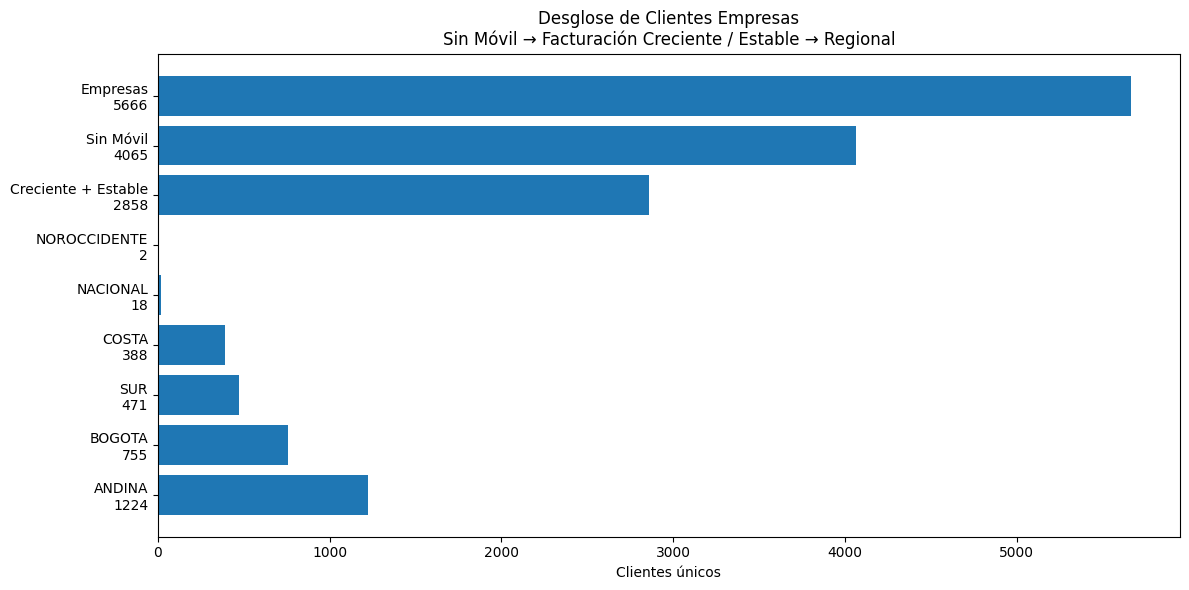

In [44]:
import matplotlib.pyplot as plt

# =====================================
# 1️⃣ FILTRO BASE SEGÚN TU DEFINICIÓN
# =====================================
base = (
    df_final[
        (df_final["SEGMENTO_2026"] == "Empresas") &
        (df_final["FIRST_LEVEL"] != "MOVIL") &
        (df_final["CATEGORIA_FACTURACION"].isin(["CRECIENTE", "ESTABLE"]))
    ][["CLIENTE_ID", "REGIONAL"]]
    .drop_duplicates(subset=["CLIENTE_ID"])
)

# =====================================
# 2️⃣ CONTEOS
# =====================================
total_empresas = (
    df_final[df_final["SEGMENTO_2026"] == "Empresas"]
    ["CLIENTE_ID"].nunique()
)

sin_movil = (
    df_final[
        (df_final["SEGMENTO_2026"] == "Empresas") &
        (df_final["FIRST_LEVEL"] != "MOVIL")
    ]["CLIENTE_ID"].nunique()
)

creciente_estable = base["CLIENTE_ID"].nunique()

regional_counts = (
    base
    .groupby("REGIONAL")["CLIENTE_ID"]
    .nunique()
    .sort_values(ascending=True)
)

# =====================================
# 3️⃣ ARMAR ETIQUETAS DEL ÁRBOL
# =====================================
labels = (
    [f"Empresas\n{total_empresas}"] +
    [f"Sin Móvil\n{sin_movil}"] +
    [f"Creciente + Estable\n{creciente_estable}"] +
    [f"{reg}\n{cnt}" for reg, cnt in regional_counts.items()]
)

values = (
    [total_empresas] +
    [sin_movil] +
    [creciente_estable] +
    regional_counts.tolist()
)

y_pos = range(len(values))

# =====================================
# 4️⃣ VISUAL
# =====================================
plt.figure(figsize=(12, 6))
plt.barh(y_pos, values)
plt.yticks(y_pos, labels)
plt.gca().invert_yaxis()

plt.title(
    "Desglose de Clientes Empresas\n"
    "Sin Móvil → Facturación Creciente / Estable → Regional"
)
plt.xlabel("Clientes únicos")

plt.tight_layout()
plt.show()
